# Lab 4 Report: 
## Surpass Human Performance in Fashion MNIST Classificaion

### Nate Chaoweeraprasit

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

In [8]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [17]:
# from google.colab import files
# uploaded = files.upload()

from google.colab import drive
drive.mount('/content/drive/MyDrive/phys_417/lab_04')

ValueError: Mountpoint must be in a directory that exists

In [14]:
Image('lab4_exercise.png', width = 1000)

FileNotFoundError: No such file or directory: 'lab4_exercise.png'

FileNotFoundError: No such file or directory: 'lab4_exercise.png'

<IPython.core.display.Image object>

## Prepare Data

In [7]:
# Load Fashion-MNIST Dataset in Numpy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f'\nusing device: {device}\n')

# 10000 training features/targets where each feature is a greyscale image with shape (28, 28)
train_features = np.load('fashion_mnist_train_features.npy') 
train_targets = np.load('fashion_mnist_train_targets.npy')

# 1000 testing features/targets 
test_features = np.load('fashion_mnist_test_features.npy')
test_targets = np.load('fashion_mnist_test_targets.npy')

# Let's see the shapes of training/testing datasets
print("Training Features Shape: ", train_features.shape)
print("Training Targets Shape: ", train_targets.shape)
print("Testing Features Shape: ", test_features.shape)
print("Testing Targets Shape: ", test_targets.shape)


using device: cpu



FileNotFoundError: [Errno 2] No such file or directory: 'fashion_mnist_train_features.npy'

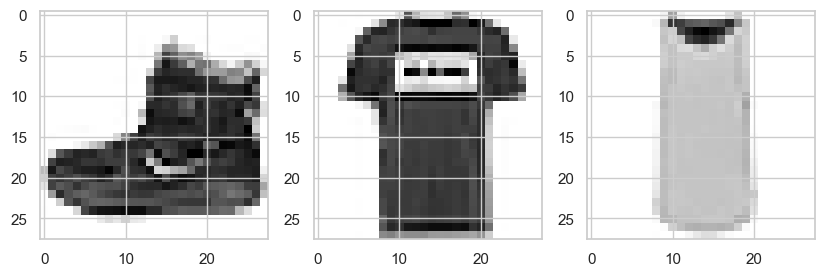

In [ ]:
# Visualizing the first three training features (samples)

plt.figure(figsize = (10, 10))

plt.subplot(1,3,1)
plt.imshow(train_features[0], cmap = 'Greys')

plt.subplot(1,3,2)
plt.imshow(train_features[1], cmap = 'Greys')

plt.subplot(1,3,3)
plt.imshow(train_features[2], cmap = 'Greys')

In [ ]:
# Reshape features via flattening the images
# This refers to reshape each sample from a 2d array to a 1d array.
# hint: np.reshape() function could be useful here

train_features = train_features.reshape(train_features.shape[0], -1)
test_features = test_features.reshape(test_features.shape[0], -1)

In [ ]:
# Define your scaling function
# scaling function
def scale_data(arr):
    # Calculate the mean and standard deviation of the array
    mean = np.mean(arr, axis=0)
    std = np.std(arr, axis=0)
    
    # Scale the data using standard scaling
    scaled_arr = (arr - mean) / std
    
    return scaled_arr

# Scale the dataset according to standard scaling
train_features = scale_data(train_features)
test_features = scale_data(test_features)

/var/folders/ts/vcw0nx0n0gj2z5nf313936kh0000gn/T/ipykernel_3758/718558266.py:9: RuntimeWarning: invalid value encountered in divide
  scaled_arr = (arr - mean) / std


In [ ]:
# Take the first 1000 (or randomly select 1000) training features and targets as validation set 

validation_features = train_features[:1000]
validation_targets = train_targets[:1000]

# Take the remaining 9000 training features and targets as training set 

train_features = train_features[1000:]
train_targets = train_targets[1000:]

In [ ]:
# Reshape train/validation/test sets to conform to PyTorch's (N, Channels, Height, Width) standard for CNNs
channels = 1
height = 28
width = 28

train_features = train_features.reshape(train_features.shape[0], channels, height, width)
validation_features = validation_features.reshape(validation_features.shape[0], channels, height, width)
test_features = test_features.reshape(test_features.shape[0], channels, height, width)

## Define Model

In [ ]:
# Define your CNN architecture here

class CNNModel(torch.nn.Module):
    
    def __init__(self):
        
        super(CNNModel, self).__init__()
        
        # 1st convolution [N, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels = 1,
                               out_channels = 64,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)
        
        # 1st max pool 
        self.maxpool1 = nn.MaxPool2d(kernel_size = 2)

        # 2nd convolution 
        self.conv2 = nn.Conv2d(in_channels = 64,
                               out_channels = 128,
                               kernel_size = 3,
                               stride = 1,
                               padding = 1)

        # 2nd max pool
        self.maxpool2 = nn.MaxPool2d(kernel_size = 2)

        # 1st fully connected layer
        self.fc1 = nn.Linear(in_features = 128*7*7,
                             out_features = 32)
        
        # 2nd fully connected layer
        self.fc2 = nn.Linear(in_features = 32,
                             out_features = 10)
        
        # other layers we may need idk
        self.relu = nn.ReLU()

    
    def forward(self, x):
        
        # YOUR CODE HERE
        # Note: If you are using CrossEntropyLoss() do NOT apply softmax to the final ouput 
        # since it's incorporated within the loss function

        # x starts as [N, 1, 28, 28]

        # convolutional layer 1 + max pool
        out = self.conv1(x)
        out = self.relu(out)
        out = self.maxpool1(out)

        # convolutional layer 2 + max pool
        out = self.conv2(out)
        out = self.relu(out)
        out = self.maxpool2(out)

        # flatten
        out = out.view(out.size(0), -1) 

        # 1st fully connected layer
        out = self.fc1(out)
        out = self.relu(out)
        #out = self.dropout(out)

        # 2nd fully connected layer
        out = self.fc2(out)

        return out

## Select Hyperparameters

In [ ]:
# Fix the random seed so that model performance is reproducible
torch.manual_seed(55)

# Initialize your CNN model

model = CNNModel().to(device)

# Define learning rate, epoch and batchsize for mini-batch gradient

learning_rate = 0.0086
epochs = 60
batchsize = 90

# Define loss function and optimizer

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

model

CNNModel(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
  (relu): ReLU()
)

## Identify Tracked Values

In [ ]:
# Placeholders for training loss and validation accuracy during training
# Training loss should be tracked for each iteration (1 iteration -> single forward pass to the network)
# Validation accuracy should be evaluated every 'Epoch' (1 epoch -> full training dataset)
# If using batch gradient, 1 iteration = 1 epoch

train_loss_list = []
validation_accuracy_list = np.zeros((epochs,))

## Train Model

In [ ]:
import tqdm # Use "for epoch in tqdm.trange(epochs):" to see the progress bar

# Convert the training, validation, testing dataset (NumPy arrays) into torch tensors
# Split your training features/targets into mini-batches if using mini-batch gradient

train_inputs = torch.from_numpy(train_features).float().to(device)
train_targets = torch.from_numpy(train_targets).long().to(device)

validation_inputs = torch.from_numpy(validation_features).float().to(device)
validation_targets = torch.from_numpy(validation_targets).long().to(device)

testing_inputs = torch.from_numpy(test_features).float().to(device)
testing_targets = torch.from_numpy(test_targets).long().to(device)

train_batches_features = torch.split(train_inputs, batchsize)
train_batches_targets = torch.split(train_targets, batchsize)

# length of train_batches_features = total number of mini-batches in the training set
batch_split_num = len(train_batches_features)

# Training Loop ---------------------------------------------------------------------------------------

for epoch in range(epochs):

    # For each mini-batch number i, grab i-th training feature mini-batch and target mini-batch
    # and perform fwd/bwd pass on the network
    
    for batch_num in range(batch_split_num):
        optimizer.zero_grad()
        train_batch_outputs = model(train_batches_features[batch_num])
        loss = loss_func(train_batch_outputs, train_batches_targets[batch_num])
        train_loss_list.append(loss.item())
        loss.backward()
        optimizer.step()
    

    # Compute Validation Accuracy ----------------------------------------------------------------------
    with torch.no_grad():
        validation_outputs = model(validation_inputs)
        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets).type(torch.FloatTensor)

        print(f"epoch {epoch+1:02d} | val accuracy: {correct.mean():.3f}")

        validation_accuracy_list[epoch] = correct.mean()


epoch 01 | val accuracy: 0.671
epoch 02 | val accuracy: 0.738
epoch 03 | val accuracy: 0.752
epoch 04 | val accuracy: 0.771
epoch 05 | val accuracy: 0.785
epoch 06 | val accuracy: 0.800
epoch 07 | val accuracy: 0.812
epoch 08 | val accuracy: 0.817
epoch 09 | val accuracy: 0.825
epoch 10 | val accuracy: 0.834
epoch 11 | val accuracy: 0.843
epoch 12 | val accuracy: 0.845
epoch 13 | val accuracy: 0.850
epoch 14 | val accuracy: 0.853
epoch 15 | val accuracy: 0.851
epoch 16 | val accuracy: 0.849
epoch 17 | val accuracy: 0.853
epoch 18 | val accuracy: 0.855
epoch 19 | val accuracy: 0.858
epoch 20 | val accuracy: 0.859
epoch 21 | val accuracy: 0.862
epoch 22 | val accuracy: 0.865
epoch 23 | val accuracy: 0.863
epoch 24 | val accuracy: 0.866
epoch 25 | val accuracy: 0.866
epoch 26 | val accuracy: 0.868
epoch 27 | val accuracy: 0.870
epoch 28 | val accuracy: 0.872
epoch 29 | val accuracy: 0.872
epoch 30 | val accuracy: 0.871
epoch 31 | val accuracy: 0.873
epoch 32 | val accuracy: 0.873
epoch 33

## Visualize & Evaluate Model

In [ ]:
# Seaborn for prettier plot

import seaborn as sns

sns.set(style = 'whitegrid', font_scale = 1)

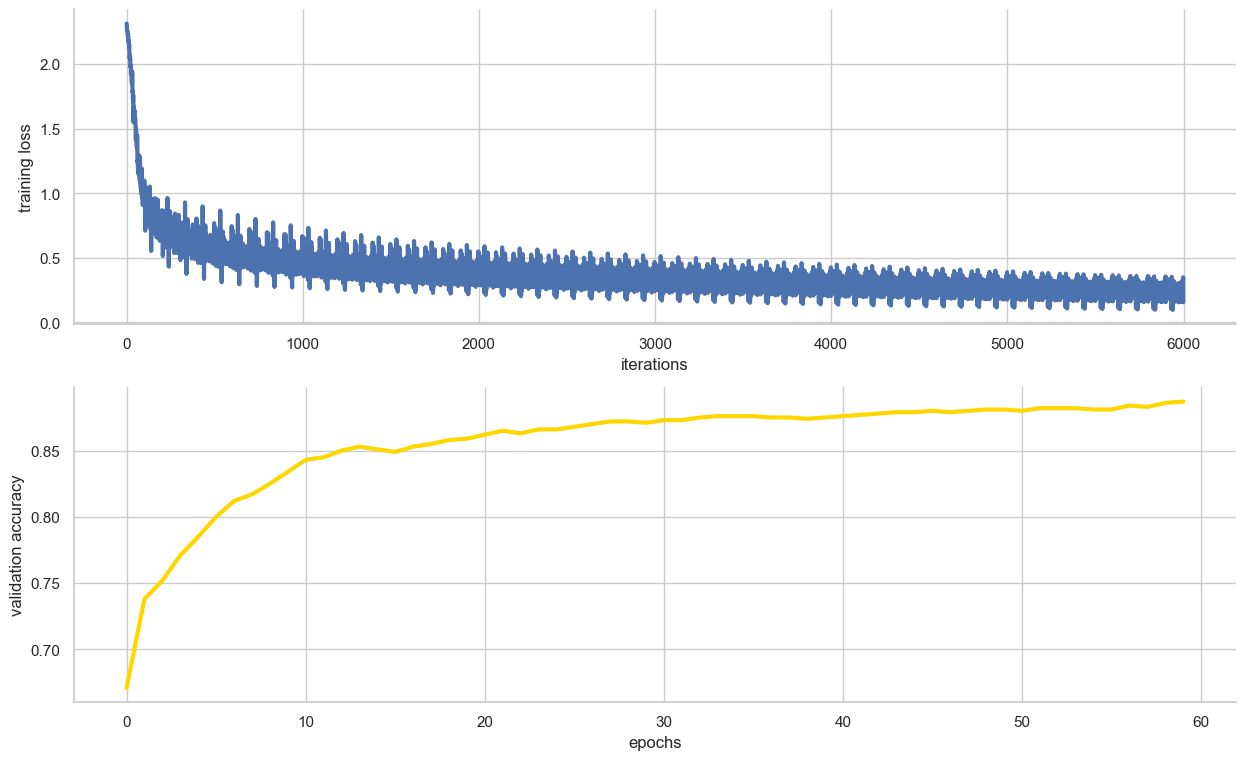

In [ ]:
# Visualize training loss

plt.figure(figsize = (15, 9))

plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.xlabel("iterations")
plt.ylabel("training loss")
sns.despine()

plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.xlabel("epochs")
plt.ylabel("validation accuracy")
sns.despine()

In [ ]:
# Compute the testing accuracy 

with torch.no_grad():
        
    testing_outputs = model(testing_inputs)
    prediction = torch.argmax(testing_outputs, dim=1)
    correct = (prediction == testing_targets).type(torch.FloatTensor)
    
print(f"Testing Accuracy: {correct.mean():.3f}")

Testing Accuracy: 0.875


In [ ]:
# (OPTIONAL) Print the testing accuracy for each fashion class. Your code should produce something that looks like:
# Clever usage of np.where() could be useful here

# "Accuracy of T-shirt/top: 93.5 %"
# "Accuracy of Trouser: 89.3 %"
# etc...

# What's the fashion item that your model had the hardest time classifying?

# YOUR CODE HERE